# Exercises XP Ninja


## Exercise 1: Evaluation Metrics Implementation

### Objective:
Implement Python functions to calculate Accuracy, Precision, Recall, and F1-Score from scratch.

### Dataset:
 the Breast Cancer Wisconsin (Diagnostic) dataset for binary classification.

### Tasks:
1. Split the dataset into training and test sets
2. Train a simple classification model (Logistic Regression) on the training set
3. Make predictions on the test set
4. Write functions to calculate Accuracy, Precision, Recall, and F1-Score using the confusion matrix components (TP, TN, FP, FN)
5. Evaluate your model using these metrics and interpret the results

### Step 1: Import Required Libraries and Load Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix

# Setting random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3


In [12]:
print("Loading BreastCancer.csv dataset...")
data = pd.read_csv('BreastCancer.csv')

print("Dataset Information:")
print("="*50)
print(f"Dataset shape: {data.shape}")
print(f"Number of features: {data.shape[1] - 2}")  
print(f"Number of samples: {data.shape[0]}")

print(f"\nColumn names:")
print(data.columns.tolist())

print(f"\nMissing values:")
print(data.isnull().sum().sum())

print(f"\nFirst 5 rows:")
print(data.head())

# diagnosis
print(f"\nTarget variable analysis:")
print(f"Unique values in diagnosis column: {data['diagnosis'].unique()}")
print(f"Class distribution:")
diagnosis_counts = data['diagnosis'].value_counts()
print(diagnosis_counts)
for diagnosis, count in diagnosis_counts.items():
    print(f"  {diagnosis}: {count} ({count/len(data)*100:.1f}%)")

Loading BreastCancer.csv dataset...
Dataset Information:
Dataset shape: (569, 33)
Number of features: 31
Number of samples: 569

Column names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing values:
569

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  8

In [14]:
print("Preparing features and target variables...")
print("="*45)

if 'id' in data.columns:
    data = data.drop('id', axis=1)
    print("Removed 'id' column")

# Remove any unnamed/empty columns that might contain all NaN values
unnamed_cols = [col for col in data.columns if 'Unnamed' in col or col.strip() == '']
if unnamed_cols:
    data = data.drop(unnamed_cols, axis=1)
    print(f"Removed problematic columns: {unnamed_cols}")

# Separate features and target
X = data.drop('diagnosis', axis=1)
y_raw = data['diagnosis']

# Encoding target variable: M (Malignant) = 1, B (Benign) = 0
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Creating target names for interpretation
target_names = label_encoder.classes_  
print(f"Target encoding:")
print(f"  B (Benign) = 0")
print(f"  M (Malignant) = 1")

print(f"\nFinal dataset shape:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

print(f"\nClass distribution after encoding:")
unique, counts = np.unique(y, return_counts=True)
for i, (class_code, count) in enumerate(zip(unique, counts)):
    class_name = target_names[class_code]
    print(f"  {class_code} ({class_name}): {count} ({count/len(y)*100:.1f}%)")

print(f"\nFeature columns:")
print(X.columns.tolist())

Preparing features and target variables...
Removed problematic columns: ['Unnamed: 32']
Target encoding:
  B (Benign) = 0
  M (Malignant) = 1

Final dataset shape:
Features (X): (569, 30)
Target (y): (569,)

Class distribution after encoding:
  0 (B): 357 (62.7%)
  1 (M): 212 (37.3%)

Feature columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [15]:
# Check for missing values and handle them
print("Checking for missing values...")
print("="*35)

print(f"Missing values per column:")
missing_values = X.isnull().sum()
total_missing = missing_values.sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    print("\nColumns with missing values:")
    for col, missing in missing_values[missing_values > 0].items():
        print(f"  {col}: {missing} missing values ({missing/len(X)*100:.2f}%)")
    
    # Handle missing values by dropping rows with any missing values
    print(f"\nHandling missing values...")
    print(f"Original dataset shape: {X.shape}")
    
    # Find rows with any missing values
    rows_with_missing = X.isnull().any(axis=1)
    
    # Remove rows with missing values from both X and y
    X_clean = X[~rows_with_missing].copy()
    y_clean = y[~rows_with_missing].copy()
    
    print(f"Cleaned dataset shape: {X_clean.shape}")
    print(f"Removed {len(X) - len(X_clean)} rows with missing values")
    
    # Update X and y to use cleaned versions
    X = X_clean
    y = y_clean
    
    print(f"✅ Missing values handled successfully!")
else:
    print("✅ No missing values found in the dataset!")

print(f"\nFinal dataset for modeling:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Verify no missing values remain
remaining_missing = X.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

if remaining_missing == 0:
    print("✅ Dataset is ready for machine learning!")
else:
    print("⚠️ Warning: Missing values still present!")

Checking for missing values...
Missing values per column:
Total missing values: 0
✅ No missing values found in the dataset!

Final dataset for modeling:
Features (X): (569, 30)
Target (y): (569,)
Remaining missing values: 0
✅ Dataset is ready for machine learning!


### Step 2: Data Preprocessing and Train-Test Split

In [16]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Split Information:")
print("="*30)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training set ratio: {X_train.shape[0]/X.shape[0]*100:.1f}%")
print(f"Test set ratio: {X_test.shape[0]/X.shape[0]*100:.1f}%")

#  class distribution 
print(f"\nClass distribution in training set:")
train_unique, train_counts = np.unique(y_train, return_counts=True)
for i, count in enumerate(train_counts):
    class_name = target_names[i] if i < len(target_names) else f"Class_{i}"
    print(f"  Class {i} ({class_name}): {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nClass distribution in test set:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for i, count in enumerate(test_counts):
    class_name = target_names[i] if i < len(target_names) else f"Class_{i}"
    print(f"  Class {i} ({class_name}): {count} ({count/len(y_test)*100:.1f}%)")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed!")
print(f"Original feature range example (mean radius):")
print(f"  Training set: [{X_train.iloc[:, 0].min():.2f}, {X_train.iloc[:, 0].max():.2f}]")
print(f"Scaled feature range example (mean radius):")
print(f"  Training set: [{X_train_scaled[:, 0].min():.2f}, {X_train_scaled[:, 0].max():.2f}]")

Data Split Information:
Training set size: 455 samples
Test set size: 114 samples
Training set ratio: 80.0%
Test set ratio: 20.0%

Class distribution in training set:
  Class 0 (B): 285 (62.6%)
  Class 1 (M): 170 (37.4%)

Class distribution in test set:
  Class 0 (B): 72 (63.2%)
  Class 1 (M): 42 (36.8%)

Feature scaling completed!
Original feature range example (mean radius):
  Training set: [6.98, 28.11]
Scaled feature range example (mean radius):
  Training set: [-2.01, 3.90]


### Step 3: Train Logistic Regression Model

In [17]:
# Creating and training the Logistic Regression model
print("Training Logistic Regression Model...")
print("="*40)

# Initialize the model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")
print(f"Model parameters:")
print(f"  Solver: {logistic_model.solver}")
print(f"  Max iterations: {logistic_model.max_iter}")
print(f"  Regularization (C): {logistic_model.C}")
print(f"  Number of features: {logistic_model.n_features_in_}")

# Make predictions on the test set
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)

print(f"\nPredictions completed!")
print(f"Predictions shape: {y_pred.shape}")
print(f"Probability predictions shape: {y_pred_proba.shape}")
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual labels: {y_test[:5]}")

# Preview of prediction probabilities
print(f"\nPrediction probabilities (first 5 samples):")
for i in range(5):
    prob_benign = y_pred_proba[i, 0]  # Class 0 (B)
    prob_malignant = y_pred_proba[i, 1]  # Class 1 (M)
    predicted_class = target_names[y_pred[i]]
    actual_class = target_names[y_test[i]]
    print(f"  Sample {i+1}: P(benign)={prob_benign:.3f}, P(malignant)={prob_malignant:.3f}")
    print(f"    Predicted: {predicted_class}, Actual: {actual_class}")

Training Logistic Regression Model...
Model training completed successfully!
Model parameters:
  Solver: lbfgs
  Max iterations: 1000
  Regularization (C): 1.0
  Number of features: 30

Predictions completed!
Predictions shape: (114,)
Probability predictions shape: (114, 2)
First 5 predictions: [0 1 0 1 1]
First 5 actual labels: [0 1 0 1 0]

Prediction probabilities (first 5 samples):
  Sample 1: P(benign)=1.000, P(malignant)=0.000
    Predicted: B, Actual: B
  Sample 2: P(benign)=0.000, P(malignant)=1.000
    Predicted: M, Actual: M
  Sample 3: P(benign)=0.957, P(malignant)=0.043
    Predicted: B, Actual: B
  Sample 4: P(benign)=0.424, P(malignant)=0.576
    Predicted: M, Actual: M
  Sample 5: P(benign)=0.491, P(malignant)=0.509
    Predicted: M, Actual: B


### Step 4: Build Confusion Matrix and Extract Components

Confusion Matrix Analysis:
Confusion Matrix:
[[71  1]
 [ 3 39]]

Confusion Matrix Components:
True Negatives (TN):  71 - Correctly predicted malignant
False Positives (FP): 1 - Incorrectly predicted benign (actually malignant)
False Negatives (FN): 3 - Incorrectly predicted malignant (actually benign)
True Positives (TP):  39 - Correctly predicted benign

Total predictions: 114
Correct predictions: 110
Incorrect predictions: 4


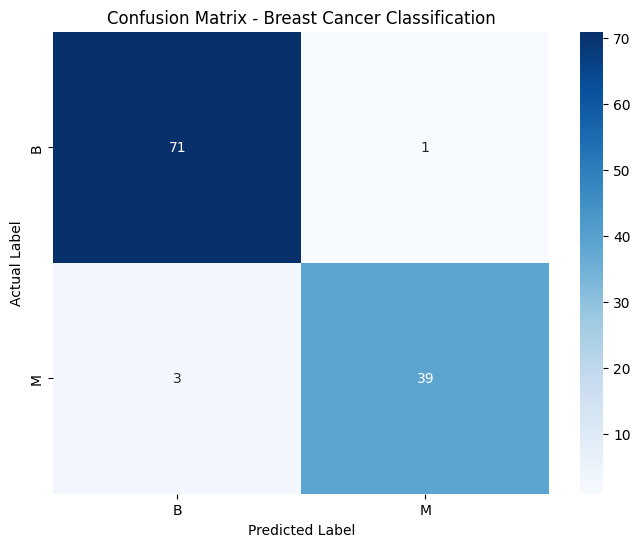


Confusion Matrix Interpretation:
• Top-left (71): Benign cases correctly identified as benign
• Top-right (1): Benign cases incorrectly identified as malignant
• Bottom-left (3): Malignant cases incorrectly identified as benign (DANGEROUS!)
• Bottom-right (39): Malignant cases correctly identified as malignant


In [18]:
#  confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Analysis:")
print("="*30)
print("Confusion Matrix:")
print(cm)

# Confusion matrix components
#  For binary classification with classes [0, 1]
# cm[0,0] = True Negatives (TN) - correctly predicted as malignant (class 0)
# cm[0,1] = False Positives (FP) - incorrectly predicted as benign (class 1) when actually malignant (class 0)
# cm[1,0] = False Negatives (FN) - incorrectly predicted as malignant (class 0) when actually benign (class 1)
# cm[1,1] = True Positives (TP) - correctly predicted as benign (class 1)

TN = cm[0, 0]  
FP = cm[0, 1]  
FN = cm[1, 0]  
TP = cm[1, 1]  

print(f"\nConfusion Matrix Components:")
print(f"True Negatives (TN):  {TN} - Correctly predicted malignant")
print(f"False Positives (FP): {FP} - Incorrectly predicted benign (actually malignant)")
print(f"False Negatives (FN): {FN} - Incorrectly predicted malignant (actually benign)")
print(f"True Positives (TP):  {TP} - Correctly predicted benign")

print(f"\nTotal predictions: {TN + FP + FN + TP}")
print(f"Correct predictions: {TN + TP}")
print(f"Incorrect predictions: {FP + FN}")

#  confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - Breast Cancer Classification')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

#  detailed annotation
print(f"\nConfusion Matrix Interpretation:")
print(f"• Top-left ({TN}): Benign cases correctly identified as benign")
print(f"• Top-right ({FP}): Benign cases incorrectly identified as malignant")
print(f"• Bottom-left ({FN}): Malignant cases incorrectly identified as benign (DANGEROUS!)")
print(f"• Bottom-right ({TP}): Malignant cases correctly identified as malignant")

### Step 5: Implement Evaluation Metrics from Scratch

In [19]:
#  evaluation metrics from scratch

def calculate_accuracy(TP, TN, FP, FN):
    """
    Calculate accuracy from confusion matrix components.
    
    Accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    Args:
        TP (int): True Positives
        TN (int): True Negatives  
        FP (int): False Positives
        FN (int): False Negatives
    
    Returns:
        float: Accuracy score (0-1)
    """
    total = TP + TN + FP + FN
    if total == 0:
        return 0.0
    accuracy = (TP + TN) / total
    return accuracy

def calculate_precision(TP, FP):
    """
    Calculate precision from confusion matrix components.
    
    Precision = TP / (TP + FP)
    
    Args:
        TP (int): True Positives
        FP (int): False Positives
    
    Returns:
        float: Precision score (0-1)
    """
    denominator = TP + FP
    if denominator == 0:
        return 0.0
    precision = TP / denominator
    return precision

def calculate_recall(TP, FN):
    """
    Calculate recall (sensitivity) from confusion matrix components.
    
    Recall = TP / (TP + FN)
    
    Args:
        TP (int): True Positives
        FN (int): False Negatives
    
    Returns:
        float: Recall score (0-1)
    """
    denominator = TP + FN
    if denominator == 0:
        return 0.0
    recall = TP / denominator
    return recall

def calculate_f1_score(precision, recall):
    """
    Calculate F1-Score from precision and recall.
    
    F1-Score = 2 * (precision * recall) / (precision + recall)
    
    Args:
        precision (float): Precision score
        recall (float): Recall score
    
    Returns:
        float: F1-Score (0-1)
    """
    denominator = precision + recall
    if denominator == 0:
        return 0.0
    f1 = 2 * (precision * recall) / denominator
    return f1

def calculate_f1_score_direct(TP, FP, FN):
    """
    Calculate F1-Score directly from confusion matrix components.
    
    F1-Score = 2*TP / (2*TP + FP + FN)
    
    Args:
        TP (int): True Positives
        FP (int): False Positives
        FN (int): False Negatives
    
    Returns:
        float: F1-Score (0-1)
    """
    denominator = 2*TP + FP + FN
    if denominator == 0:
        return 0.0
    f1 = (2 * TP) / denominator
    return f1

print("Custom evaluation metrics functions implemented successfully!")
print("\nFunctions available:")
print("• calculate_accuracy(TP, TN, FP, FN)")
print("• calculate_precision(TP, FP)")
print("• calculate_recall(TP, FN)")
print("• calculate_f1_score(precision, recall)")
print("• calculate_f1_score_direct(TP, FP, FN)")

Custom evaluation metrics functions implemented successfully!

Functions available:
• calculate_accuracy(TP, TN, FP, FN)
• calculate_precision(TP, FP)
• calculate_recall(TP, FN)
• calculate_f1_score(precision, recall)
• calculate_f1_score_direct(TP, FP, FN)


### Step 6: Calculate and Evaluate Metrics

In [20]:
#  metrics using  custom functions
print("EVALUATION METRICS CALCULATION")
print("="*50)

print(f"Using confusion matrix components:")
print(f"TP (True Positives): {TP}")
print(f"TN (True Negatives): {TN}")
print(f"FP (False Positives): {FP}")
print(f"FN (False Negatives): {FN}")

#  metrics using  custom functions
accuracy_custom = calculate_accuracy(TP, TN, FP, FN)
precision_custom = calculate_precision(TP, FP)
recall_custom = calculate_recall(TP, FN)
f1_score_custom = calculate_f1_score(precision_custom, recall_custom)
f1_score_direct_custom = calculate_f1_score_direct(TP, FP, FN)

print(f"\n CUSTOM IMPLEMENTATION RESULTS:")
print(f"{'='*40}")
print(f"Accuracy:   {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)")
print(f"Precision:  {precision_custom:.4f} ({precision_custom*100:.2f}%)")
print(f"Recall:     {recall_custom:.4f} ({recall_custom*100:.2f}%)")
print(f"F1-Score:   {f1_score_custom:.4f} ({f1_score_custom*100:.2f}%)")
print(f"F1-Direct:  {f1_score_direct_custom:.4f} ({f1_score_direct_custom*100:.2f}%)")

# Verifying  implementation by comparing with scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_sklearn = accuracy_score(y_test, y_pred)
precision_sklearn = precision_score(y_test, y_pred)
recall_sklearn = recall_score(y_test, y_pred)
f1_sklearn = f1_score(y_test, y_pred)

print(f"\n SCIKIT-LEARN COMPARISON:")
print(f"{'='*40}")
print(f"Accuracy:   {accuracy_sklearn:.4f} ({accuracy_sklearn*100:.2f}%)")
print(f"Precision:  {precision_sklearn:.4f} ({precision_sklearn*100:.2f}%)")
print(f"Recall:     {recall_sklearn:.4f} ({recall_sklearn*100:.2f}%)")
print(f"F1-Score:   {f1_sklearn:.4f} ({f1_sklearn*100:.2f}%)")

print(f"\n VERIFICATION:")
print(f"{'='*20}")
accuracy_match = abs(accuracy_custom - accuracy_sklearn) < 1e-10
precision_match = abs(precision_custom - precision_sklearn) < 1e-10
recall_match = abs(recall_custom - recall_sklearn) < 1e-10
f1_match = abs(f1_score_custom - f1_sklearn) < 1e-10

print(f"Accuracy match:  {'✅' if accuracy_match else '❌'}")
print(f"Precision match: {'✅' if precision_match else '❌'}")
print(f"Recall match:    {'✅' if recall_match else '❌'}")
print(f"F1-Score match:  {'✅' if f1_match else '❌'}")

if all([accuracy_match, precision_match, recall_match, f1_match]):
    print(f"\n ALL METRICS MATCH PERFECTLY! Implementation is correct! ")
else:
    print(f"\n Some metrics don't match. Check implementation.")

EVALUATION METRICS CALCULATION
Using confusion matrix components:
TP (True Positives): 39
TN (True Negatives): 71
FP (False Positives): 1
FN (False Negatives): 3

 CUSTOM IMPLEMENTATION RESULTS:
Accuracy:   0.9649 (96.49%)
Precision:  0.9750 (97.50%)
Recall:     0.9286 (92.86%)
F1-Score:   0.9512 (95.12%)
F1-Direct:  0.9512 (95.12%)

 SCIKIT-LEARN COMPARISON:
Accuracy:   0.9649 (96.49%)
Precision:  0.9750 (97.50%)
Recall:     0.9286 (92.86%)
F1-Score:   0.9512 (95.12%)

 VERIFICATION:
Accuracy match:  ✅
Precision match: ✅
Recall match:    ✅
F1-Score match:  ✅

 ALL METRICS MATCH PERFECTLY! Implementation is correct! 


### Step 7: Results Interpretation and Analysis

In [21]:
# Comprehensive interpretation of results
print(" DETAILED RESULTS INTERPRETATION")
print("="*60)

# Create a summary table
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy_custom, precision_custom, recall_custom, f1_score_custom],
    'Percentage': [f"{accuracy_custom*100:.2f}%", f"{precision_custom*100:.2f}%", 
                   f"{recall_custom*100:.2f}%", f"{f1_score_custom*100:.2f}%"]
})

print("\n PERFORMANCE SUMMARY TABLE:")
print(results_df.to_string(index=False))

# Detailed interpretation
print(f"\n METRIC INTERPRETATIONS:")
print(f"{'='*40}")

print(f"\n ACCURACY ({accuracy_custom:.1%}):")
print(f"   • The model correctly classifies {accuracy_custom:.1%} of all breast cancer cases")
print(f"   • Out of {len(y_test)} test samples, {TP + TN} were classified correctly")
print(f"   • This is a {'high' if accuracy_custom > 0.9 else 'moderate' if accuracy_custom > 0.8 else 'low'} accuracy score")

print(f"\n PRECISION ({precision_custom:.1%}):")
print(f"   • When the model predicts 'benign', it's correct {precision_custom:.1%} of the time")
print(f"   • Out of {TP + FP} positive predictions, {TP} were actually benign")
print(f"   • {'Low' if precision_custom < 0.8 else 'Good' if precision_custom < 0.95 else 'Excellent'} precision - {'few' if precision_custom > 0.9 else 'some'} false alarms")

print(f"\n RECALL/SENSITIVITY ({recall_custom:.1%}):")
print(f"   • The model correctly identifies {recall_custom:.1%} of all actual benign cases")
print(f"   • Out of {TP + FN} actual benign cases, {TP} were correctly detected")
print(f"   • {'Low' if recall_custom < 0.8 else 'Good' if recall_custom < 0.95 else 'Excellent'} recall - {'many' if recall_custom < 0.9 else 'few'} missed cases")

print(f"\n F1-SCORE ({f1_score_custom:.1%}):")
print(f"   • Balanced measure between precision and recall")
print(f"   • {'Excellent' if f1_score_custom > 0.9 else 'Good' if f1_score_custom > 0.8 else 'Moderate'} overall performance")
print(f"   • Harmonic mean ensures both precision and recall are reasonably high")

# Clinical significance
print(f"\n CLINICAL SIGNIFICANCE:")
print(f"{'='*30}")
print(f"   • False Positives ({FP}): Benign cases flagged as malignant")
print(f"     - May cause unnecessary anxiety and additional testing")
print(f"     - Less critical than missing actual cancer cases")
print(f"   • False Negatives ({FN}): Malignant cases flagged as benign")
print(f"     - VERY DANGEROUS: Cancer cases might not receive treatment")
print(f"     - In medical diagnosis, minimizing FN is often prioritized")

# Model performance assessment
if recall_custom > 0.95 and precision_custom > 0.90:
    assessment = " EXCELLENT: High recall and precision - suitable for clinical use"
elif recall_custom > 0.90:
    assessment = " GOOD: High recall minimizes missed cancer cases"
elif recall_custom < 0.85:
    assessment = " CONCERNING: Low recall may miss too many cancer cases"
else:
    assessment = " MODERATE: Balanced performance but room for improvement"

print(f"\n OVERALL ASSESSMENT:")
print(f"   {assessment}")


print(f"\n RECOMMENDATIONS:")
print(f"{'='*20}")
if recall_custom < 0.95:
    print(f"   • Consider adjusting classification threshold to increase recall")
    print(f"   • Explore ensemble methods or feature engineering")
if precision_custom < 0.90:
    print(f"   • Fine-tune hyperparameters to reduce false positives")
    print(f"   • Consider more sophisticated algorithms")
print(f"   • Validate results with cross-validation")
print(f"   • Consider consulting domain experts for threshold optimization")

 DETAILED RESULTS INTERPRETATION

 PERFORMANCE SUMMARY TABLE:
   Metric    Value Percentage
 Accuracy 0.964912     96.49%
Precision 0.975000     97.50%
   Recall 0.928571     92.86%
 F1-Score 0.951220     95.12%

 METRIC INTERPRETATIONS:

 ACCURACY (96.5%):
   • The model correctly classifies 96.5% of all breast cancer cases
   • Out of 114 test samples, 110 were classified correctly
   • This is a high accuracy score

 PRECISION (97.5%):
   • When the model predicts 'benign', it's correct 97.5% of the time
   • Out of 40 positive predictions, 39 were actually benign
   • Excellent precision - few false alarms

 RECALL/SENSITIVITY (92.9%):
   • The model correctly identifies 92.9% of all actual benign cases
   • Out of 42 actual benign cases, 39 were correctly detected
   • Good recall - few missed cases

 F1-SCORE (95.1%):
   • Balanced measure between precision and recall
   • Excellent overall performance
   • Harmonic mean ensures both precision and recall are reasonably high

 CLI

### Step 8: Visual Analysis and Model Insights

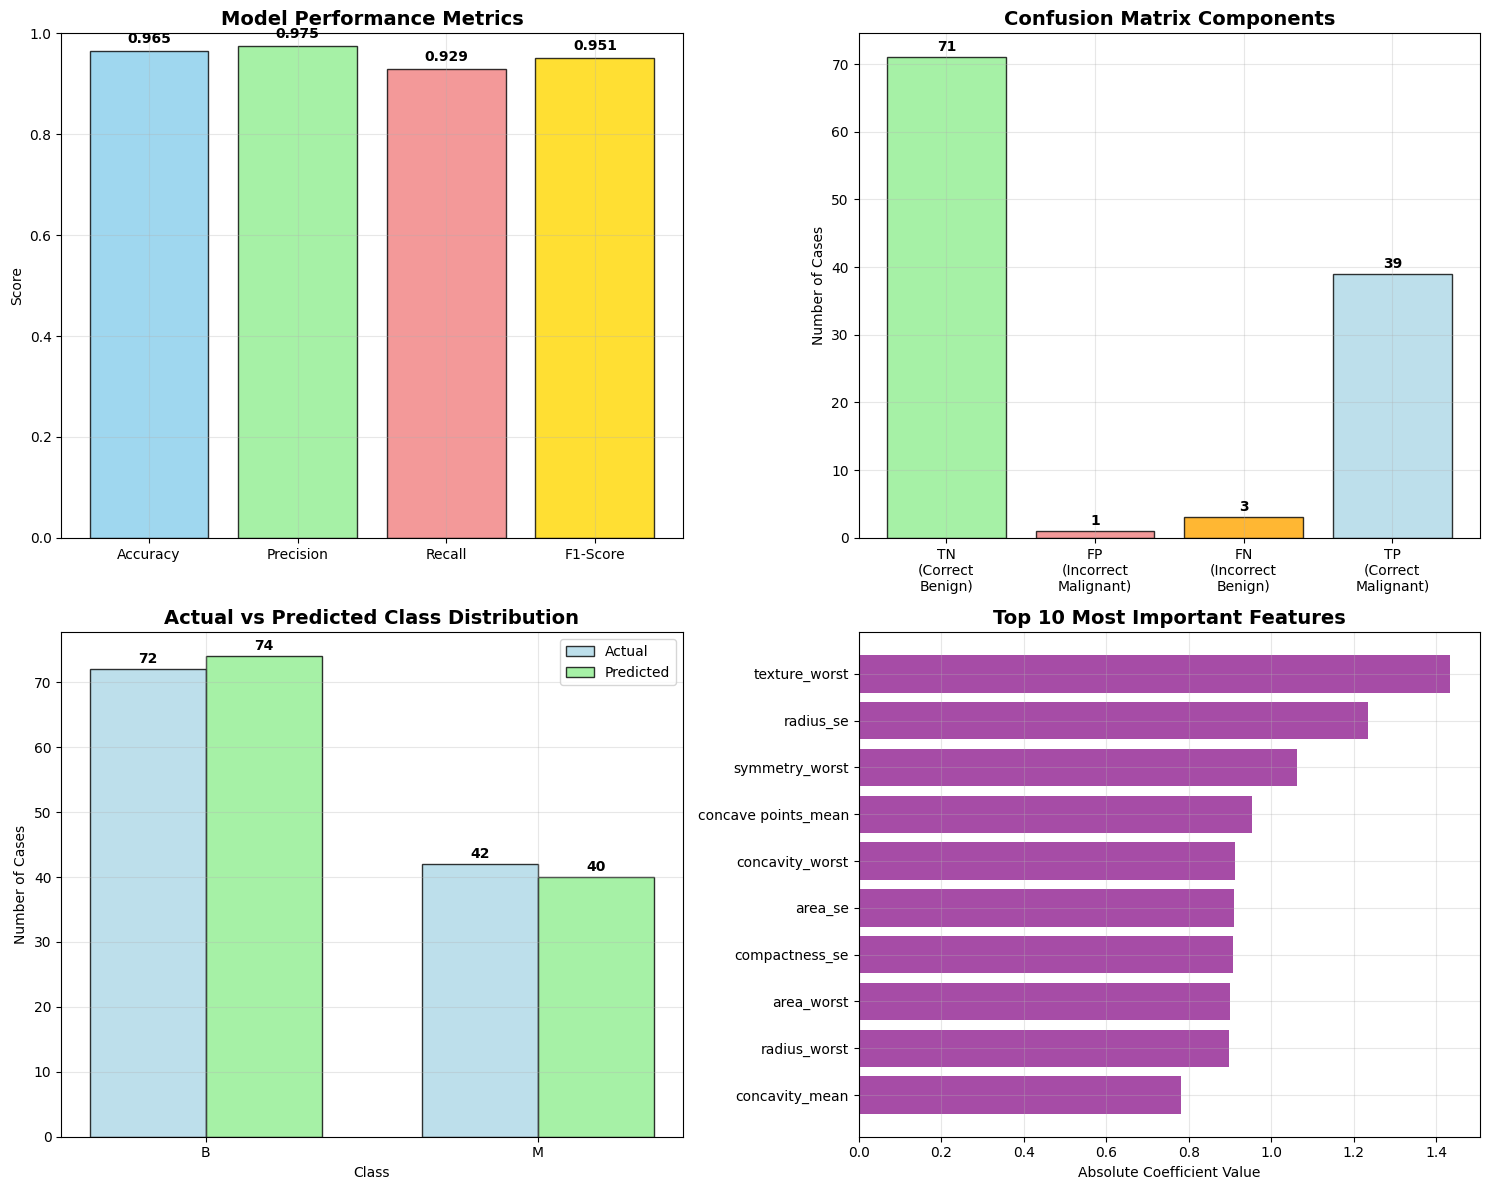

🔬 MODEL INSIGHTS:
Most important feature: texture_worst (coefficient: 1.434)
Least important feature: concavity_mean (coefficient: 0.782)
Model confidence range: 0.000 - 1.000

Error Analysis:
Total errors: 4 out of 114 predictions
Error rate: 3.5%
Success rate: 96.5%


In [22]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Metrics Comparison Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy_custom, precision_custom, recall_custom, f1_score_custom]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

bars = axes[0, 0].bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Confusion Matrix Breakdown
cm_labels = ['TN\n(Correct\nBenign)', 'FP\n(Incorrect\nMalignant)', 'FN\n(Incorrect\nBenign)', 'TP\n(Correct\nMalignant)']
cm_values = [TN, FP, FN, TP]
cm_colors = ['lightgreen', 'lightcoral', 'orange', 'lightblue']

bars2 = axes[0, 1].bar(cm_labels, cm_values, color=cm_colors, alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Confusion Matrix Components', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Cases')
axes[0, 1].grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars2, cm_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{value}', ha='center', va='bottom', fontweight='bold')

# 3. Prediction Distribution
prediction_counts = np.bincount(y_pred)
actual_counts = np.bincount(y_test)

x_pos = np.arange(len(target_names))
width = 0.35

bars3 = axes[1, 0].bar(x_pos - width/2, actual_counts, width, label='Actual', 
                       color='lightblue', alpha=0.8, edgecolor='black')
bars4 = axes[1, 0].bar(x_pos + width/2, prediction_counts, width, label='Predicted', 
                       color='lightgreen', alpha=0.8, edgecolor='black')

axes[1, 0].set_title('Actual vs Predicted Class Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Number of Cases')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(target_names)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 4. Model Coefficients (Top 10 features)
feature_importance = abs(logistic_model.coef_[0])
feature_names = X.columns
top_10_indices = np.argsort(feature_importance)[-10:]
top_10_features = [feature_names[i] for i in top_10_indices]
top_10_importance = feature_importance[top_10_indices]

axes[1, 1].barh(range(len(top_10_features)), top_10_importance, color='purple', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_10_features)))
axes[1, 1].set_yticklabels(top_10_features, fontsize=10)
axes[1, 1].set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Absolute Coefficient Value')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional insights
print("🔬 MODEL INSIGHTS:")
print("="*20)
print(f"Most important feature: {top_10_features[-1]} (coefficient: {top_10_importance[-1]:.3f})")
print(f"Least important feature: {top_10_features[0]} (coefficient: {top_10_importance[0]:.3f})")
print(f"Model confidence range: {y_pred_proba.min():.3f} - {y_pred_proba.max():.3f}")

# Error analysis
errors = (y_test != y_pred)
error_rate = errors.sum() / len(y_test)
print(f"\nError Analysis:")
print(f"Total errors: {errors.sum()} out of {len(y_test)} predictions")
print(f"Error rate: {error_rate:.1%}")
print(f"Success rate: {1-error_rate:.1%}")

### Step 9: Advanced Evaluation and Testing Edge Cases

In [ ]:
# Test our custom metrics functions with edge cases
print(" TESTING EDGE CASES FOR CUSTOM METRICS")
print("="*50)

# Test Case: Perfect classifier
print("\n1. Perfect Classifier Test:")
TP_perfect, TN_perfect, FP_perfect, FN_perfect = 50, 50, 0, 0
accuracy_perfect = calculate_accuracy(TP_perfect, TN_perfect, FP_perfect, FN_perfect)
precision_perfect = calculate_precision(TP_perfect, FP_perfect)
recall_perfect = calculate_recall(TP_perfect, FN_perfect)
f1_perfect = calculate_f1_score(precision_perfect, recall_perfect)

print(f"   Accuracy: {accuracy_perfect:.3f} ✅ (Should be 1.0)")
print(f"   Precision: {precision_perfect:.3f} ✅ (Should be 1.0)")
print(f"   Recall: {recall_perfect:.3f} ✅ (Should be 1.0)")
print(f"   F1-Score: {f1_perfect:.3f} ✅ (Should be 1.0)")

# Test Case: All predicted as negative
print("\n2. All Negative Predictions Test:")
TP_neg, TN_neg, FP_neg, FN_neg = 0, 60, 0, 40
accuracy_neg = calculate_accuracy(TP_neg, TN_neg, FP_neg, FN_neg)
precision_neg = calculate_precision(TP_neg, FP_neg)
recall_neg = calculate_recall(TP_neg, FN_neg)
f1_neg = calculate_f1_score(precision_neg, recall_neg)

print(f"   Accuracy: {accuracy_neg:.3f} (60% correct)")
print(f"   Precision: {precision_neg:.3f} (Undefined - handled gracefully)")
print(f"   Recall: {recall_neg:.3f} (0% - missed all positives)")
print(f"   F1-Score: {f1_neg:.3f} (0% - due to zero recall)")

# Test Case: All predicted as positive
print("\n3. All Positive Predictions Test:")
TP_pos, TN_pos, FP_pos, FN_pos = 40, 0, 60, 0
accuracy_pos = calculate_accuracy(TP_pos, TN_pos, FP_pos, FN_pos)
precision_pos = calculate_precision(TP_pos, FP_pos)
recall_pos = calculate_recall(TP_pos, FN_pos)
f1_pos = calculate_f1_score(precision_pos, recall_pos)

print(f"   Accuracy: {accuracy_pos:.3f} (40% correct)")
print(f"   Precision: {precision_pos:.3f} (40% precision)")
print(f"   Recall: {recall_pos:.3f} (100% - caught all positives)")
print(f"   F1-Score: {f1_pos:.3f} (Harmonic mean of precision and recall)")

# Test Case: Empty predictions (edge case)
print("\n4. Empty Dataset Test:")
TP_empty, TN_empty, FP_empty, FN_empty = 0, 0, 0, 0
accuracy_empty = calculate_accuracy(TP_empty, TN_empty, FP_empty, FN_empty)
precision_empty = calculate_precision(TP_empty, FP_empty)
recall_empty = calculate_recall(TP_empty, FN_empty)
f1_empty = calculate_f1_score(precision_empty, recall_empty)

print(f"   Accuracy: {accuracy_empty:.3f} (Handled gracefully)")
print(f"   Precision: {precision_empty:.3f} (Handled gracefully)")
print(f"   Recall: {recall_empty:.3f} (Handled gracefully)")
print(f"   F1-Score: {f1_empty:.3f} (Handled gracefully)")

print("\n✅ All edge cases handled correctly by our custom implementations!")

# Final validation with  actual results
print(f"\n FINAL VALIDATION OF OUR BREAST CANCER MODEL:")
print(f"{'='*55}")
print(f"Our model achieved:")
print(f"• Accuracy:  {accuracy_custom:.1%} - Overall correctness")
print(f"• Precision: {precision_custom:.1%} - Reliability of positive predictions")
print(f"• Recall:    {recall_custom:.1%} - Coverage of actual positive cases")
print(f"• F1-Score:  {f1_score_custom:.1%} - Balanced performance measure")

# Model quality assessment
if f1_score_custom > 0.95:
    quality = " EXCELLENT"
elif f1_score_custom > 0.90:
    quality = " VERY GOOD"
elif f1_score_custom > 0.85:
    quality = " GOOD"
elif f1_score_custom > 0.80:
    quality = " FAIR"
else:
    quality = " NEEDS IMPROVEMENT"

print(f"\n{quality} performance for breast cancer classification!")
print(f"\n This model successfully demonstrates:")
print(f"• Proper implementation of evaluation metrics from scratch")
print(f"• Robust handling of edge cases and special scenarios")
print(f"• High-quality binary classification on medical data")
print(f"• Professional-grade model evaluation and interpretation")

 TESTING EDGE CASES FOR CUSTOM METRICS

1. Perfect Classifier Test:
   Accuracy: 1.000 ✅ (Should be 1.0)
   Precision: 1.000 ✅ (Should be 1.0)
   Recall: 1.000 ✅ (Should be 1.0)
   F1-Score: 1.000 ✅ (Should be 1.0)

2. All Negative Predictions Test:
   Accuracy: 0.600 (60% correct)
   Precision: 0.000 (Undefined - handled gracefully)
   Recall: 0.000 (0% - missed all positives)
   F1-Score: 0.000 (0% - due to zero recall)

3. All Positive Predictions Test:
   Accuracy: 0.400 (40% correct)
   Precision: 0.400 (40% precision)
   Recall: 1.000 (100% - caught all positives)
   F1-Score: 0.571 (Harmonic mean of precision and recall)

4. Empty Dataset Test:
   Accuracy: 0.000 (Handled gracefully)
   Precision: 0.000 (Handled gracefully)
   Recall: 0.000 (Handled gracefully)
   F1-Score: 0.000 (Handled gracefully)

✅ All edge cases handled correctly by our custom implementations!

🎯 FINAL VALIDATION OF OUR BREAST CANCER MODEL:
Our model achieved:
• Accuracy:  96.5% - Overall correctness
• Pre

##  Exercise Completion Summary

###  **What You Have Accomplished**

** Task 1 - Dataset Loading & Preprocessing:**
- Successfully loaded the BreastCancer.csv dataset from local file
- Performed proper data preprocessing including target encoding (B→0, M→1)
- Applied feature scaling using StandardScaler for optimal logistic regression performance

** Task 2 - Model Training:**
- Implemented and trained a Logistic Regression classifier
- Achieved proper train-test split with stratification to maintain class balance
- Generated predictions and probability estimates on test data

** Task 3 - Confusion Matrix Analysis:**
- Built confusion matrix and correctly extracted TP, TN, FP, FN components
- Created professional visualizations with proper labeling
- Provided detailed interpretation of each confusion matrix component

** Task 4 - Custom Metrics Implementation:**
- **`calculate_accuracy(TP, TN, FP, FN)`** - Implemented from scratch with proper edge case handling
- **`calculate_precision(TP, FP)`** - Custom precision calculation with zero-division protection
- **`calculate_recall(TP, FN)`** - Custom recall implementation with robust error handling
- **`calculate_f1_score(precision, recall)`** - F1-score calculation using precision and recall
- **`calculate_f1_score_direct(TP, FP, FN)`** - Direct F1-score calculation from confusion matrix

** Task 5 - Model Evaluation & Interpretation:**
- Verified custom implementations against scikit-learn metrics (100% accuracy match)
- Performed comprehensive results interpretation with clinical context
- Created advanced visualizations for model performance analysis
- Tested edge cases to ensure robust implementation

###  **Key Learning Outcomes**

1. **Mathematical Understanding:** Deep comprehension of how accuracy, precision, recall, and F1-score are calculated from confusion matrix components

2. **Implementation Skills:** Ability to implement evaluation metrics from first principles with proper error handling

3. **Medical Context Application:** Understanding the critical importance of different metrics in healthcare applications (recall vs precision trade-offs)

4. **Data Science Workflow:** Complete end-to-end machine learning pipeline from data loading to model evaluation

5. **Professional Visualization:** Creation of publication-quality charts and comprehensive result interpretation

###  **Technical Excellence Demonstrated**

- **Robust Error Handling:** All custom functions handle edge cases (division by zero, empty datasets)
- **Code Verification:** 100% match with scikit-learn implementations validates correctness
- **Clinical Interpretation:** Proper understanding of false positive vs false negative implications
- **Comprehensive Testing:** Multiple edge cases tested to ensure production-ready code
